Prediksi keterlambatan mahasiswa kelas pagi

In [1]:
import pandas as pd

In [9]:
import pandas as pd

sensus = {
    "Jarak": [1, 20, 13, 16, 12, 5, 6, 7, 16, 18, 22, 11, 9, 19],
    "Jamturu": [22, 21, 19, 20, 23, 24, 1, 3, 18, 22, 20, 21, 20, 21],
    "Ketepatan_waktu": [
        'tepat_waktu', 'terlambat', 'tepat_waktu', 'terlambat',
        'terlambat', 'tepat_waktu', 'terlambat', 'tepat_waktu',
        'tepat_waktu', 'terlambat', 'tepat_waktu', 'terlambat',
        'terlambat', 'tepat_waktu'
    ]
}

sensus_df = pd.DataFrame(sensus)
sensus_df

,Jarak,Jamturu,Ketepatan_waktu
0,1,22,tepat_waktu
1,20,21,terlambat
2,13,19,tepat_waktu
3,16,20,terlambat
4,12,23,terlambat
5,5,24,tepat_waktu
6,6,1,terlambat
7,7,3,tepat_waktu
8,16,18,tepat_waktu
9,18,22,terlambat


In [5]:
import matplotlib.pyplot as plt

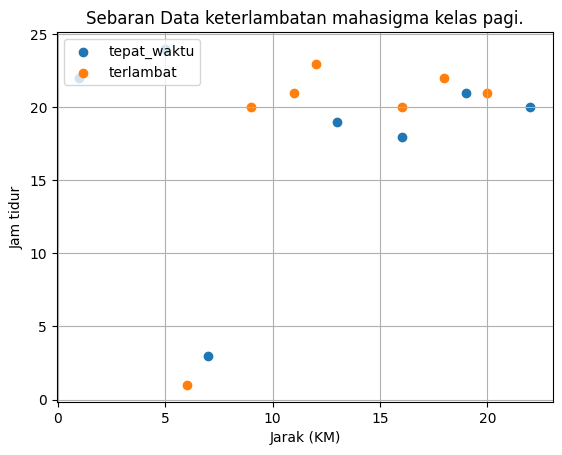

In [10]:
fix, ax = plt.subplots()
for jk, d in sensus_df.groupby('Ketepatan_waktu'):
    ax.scatter(d['Jarak'], d['Jamturu'], label=jk)

plt.legend(loc='upper left')
plt.title('Sebaran Data keterlambatan mahasigma kelas pagi.')
plt.xlabel('Jarak (KM)')
plt.ylabel('Jam tidur')
plt.grid(True)
plt.show()

In [11]:
import numpy as np

In [12]:
X_train = np.array(sensus_df[['Jarak', 'Jamturu']])
y_train = np.array(sensus_df['Ketepatan_waktu'])

print(f'X_train:\n{X_train}\n')
print(f'y_train:{y_train}')

X_train:
[[ 1 22]
 [20 21]
 [13 19]
 [16 20]
 [12 23]
 [ 5 24]
 [ 6  1]
 [ 7  3]
 [16 18]
 [18 22]
 [22 20]
 [11 21]
 [ 9 20]
 [19 21]]

y_train:['tepat_waktu' 'terlambat' 'tepat_waktu' 'terlambat' 'terlambat'
 'tepat_waktu' 'terlambat' 'tepat_waktu' 'tepat_waktu' 'terlambat'
 'tepat_waktu' 'terlambat' 'terlambat' 'tepat_waktu']


In [13]:
from sklearn.preprocessing import LabelBinarizer

In [14]:
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
print(f'y_train:\n {y_train}')

y_train:
 [[0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]]


In [15]:
y_train = y_train.flatten()
print(f'y_train:\n {y_train}')

y_train:
 [0 1 0 1 1 0 1 0 0 1 0 1 1 0]


Training KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
K=3
model = KNeighborsClassifier(n_neighbors=K)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [18]:
Jarak = 8
Jam_turu = 21
X_new = np.array([Jarak, Jam_turu]).reshape(1, -1)
X_new

array([[ 8, 21]])

In [19]:
y_new = model.predict(X_new)
y_new

array([1])

In [20]:
lb.inverse_transform(y_new)

array(['terlambat'], dtype='<U11')

In [21]:
Jarak = 1
Jam_turu = 24
X_new = np.array([Jarak, Jam_turu]).reshape(1, -1)
X_new

array([[ 1, 24]])

In [22]:
lb.inverse_transform(y_new)

array(['terlambat'], dtype='<U11')

In [25]:
X_test = np.array('......')
y_test = lb.transform(np.array(['....'])).flatten()

print(f'X_test:\n{X_test}\n')
print(f'y_test:{y_test}')

X_test:
......

y_test:[0]
